# 1. Libraries

In [1]:
import numpy as np
import pandas as pd
from IPython.display import Markdown as md
from itertools import combinations

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates
import seaborn as sns
import seaborn.objects as so

# 2. Data load

In [2]:
sheet1 = pd.read_excel("data/online_retail_II.xlsx", sheet_name="Year 2009-2010", engine="openpyxl", dtype={"Customer ID" : "Int64"})
sheet2 = pd.read_excel("data/online_retail_II.xlsx", sheet_name="Year 2010-2011", engine="openpyxl", dtype={"Customer ID" : "Int64"})

check1 = sheet1.shape[0]
check2 = sheet2.shape[0]
sum_separate = check1 + check2
sum_separate

# concat
df_raw = pd.concat([sheet1, sheet2], axis=0)
sum_concat = df_raw.shape[0]

# check rows
print(f"Check of sheets concat:{sum_separate == sum_concat}")

Check of sheets concat:True


## 2.1. Data clean

In [3]:
# to avoid loading (just in case)
df = df_raw.copy()

# whitespaces remove
df["Description"] = df["Description"].str.strip()

# revenue column
df["Revenue"] = round((df["Quantity"] * df["Price"]),2)

# date column normalize
df["InvoiceDate"] = df["InvoiceDate"].dt.normalize()

# create year-month column
df["InvoiceDate_YYYYMM"] = df["InvoiceDate"].dt.strftime("%Y-%m")

# 3. EDA

## 3.1. KDE

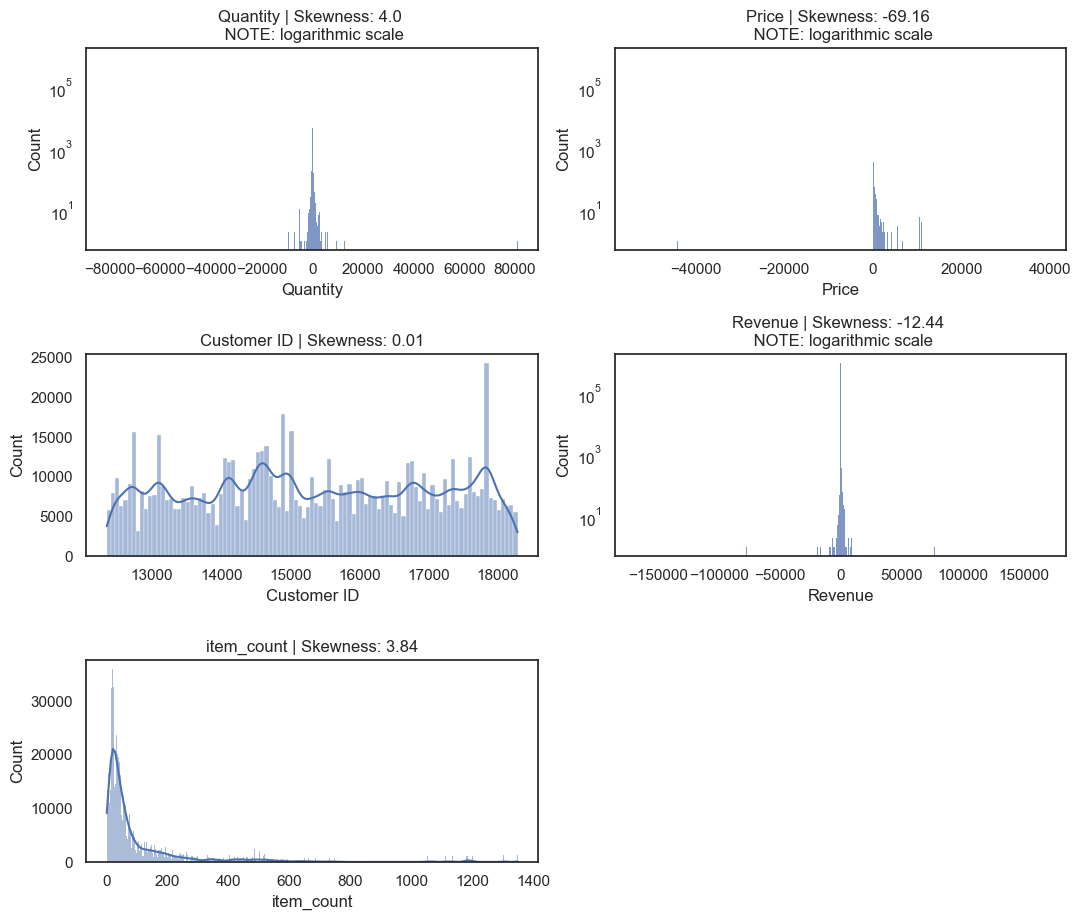

In [36]:
# KDE
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(11, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    
    if feature in ["Quantity", "Price", "Revenue"]:
        plt.title(f"{feature} | Skewness: {round(df[feature].skew(),2)} \n NOTE: logarithmic scale")
        plt.yscale("log")
        sns.histplot(df[feature], kde=False)
    else:
        plt.title(f"{feature} | Skewness: {round(df[feature].skew(),2)}") 
        sns.histplot(df[feature], kde=True)
    # plt.ticklabel_format(style='plain', axis='y')
    
    
plt.tight_layout()
plt.show()

## 3.2. Basic stats

In [5]:
# quick info
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1067371 entries, 0 to 541909
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   Invoice             1067371 non-null  object        
 1   StockCode           1067371 non-null  object        
 2   Description         1062985 non-null  object        
 3   Quantity            1067371 non-null  int64         
 4   InvoiceDate         1067371 non-null  datetime64[ns]
 5   Price               1067371 non-null  float64       
 6   Customer ID         824364 non-null   Int64         
 7   Country             1067371 non-null  object        
 8   Revenue             1067371 non-null  float64       
 9   InvoiceDate_YYYYMM  1067371 non-null  object        
dtypes: Int64(1), datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 90.6+ MB


In [6]:
# columns null check
df.isnull().sum()

Invoice                    0
StockCode                  0
Description             4386
Quantity                   0
InvoiceDate                0
Price                      0
Customer ID           243007
Country                    0
Revenue                    0
InvoiceDate_YYYYMM         0
dtype: int64

In [7]:
empty_cus_pct = round((df["Customer ID"].isnull().sum() / df["Customer ID"].shape[0]) * 100, 2)
empty_cus_row = df["Customer ID"].isnull().sum()

In [8]:
# unique values count
df.nunique()

Invoice               53628
StockCode              5305
Description            5651
Quantity               1057
InvoiceDate             604
Price                  2807
Customer ID            5942
Country                  43
Revenue                8547
InvoiceDate_YYYYMM       25
dtype: int64

In [9]:
# unique values % share
round((df.nunique() / df.count()) * 100,2)

Invoice               5.02
StockCode             0.50
Description           0.53
Quantity              0.10
InvoiceDate           0.06
Price                 0.26
Customer ID           0.72
Country               0.00
Revenue               0.80
InvoiceDate_YYYYMM    0.00
dtype: float64

In [10]:
# basic statistic
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,1067371.0,9.938898,-80995.0,1.0,3.0,10.0,80995.0,172.705794
InvoiceDate,1067371,2011-01-02 07:41:55.613034496,2009-12-01 00:00:00,2010-07-09 00:00:00,2010-12-07 00:00:00,2011-07-22 00:00:00,2011-12-09 00:00:00,NaN
Price,1067371.0,4.649388,-53594.36,1.25,2.1,4.15,38970.0,123.553059
Customer ID,824364.0,15324.638504,12346.0,13975.0,15255.0,16797.0,18287.0,1697.46445
Revenue,1067371.0,18.069866,-168469.6,3.75,9.9,17.7,168469.6,292.420223


### Quick thoughts

In [11]:
display(md(f"**{empty_cus_pct}%** rows are missing customer data. It is **{empty_cus_row}** transactions."))
display(md("The data set is highly diversified. Very low percentage of unique values. Any column can be used as category."))
display(md(f"Some outliers can be found in [Quantity] and [Price]."))
display(md(f"[Quantity] minimum value is **[{(df.describe().T.iloc[0,2])}]**, 25-50-75 percentiles are **{list(df.describe().T.iloc[0,3:6])}** and maximum value is **[{(df.describe().T.iloc[0,6])}]**."))
display(md(f"[Price] minimum value is **[{(df.describe().T.iloc[2,2])}]**, 25-50-75 percentiles are **{list(df.describe().T.iloc[2,3:6])}** and maximum value is **[{(df.describe().T.iloc[2,6])}]**."))
display(md(f"And further, this is continued in [Revenue] because it is the result of both of these columns."))

**22.77%** rows are missing customer data. It is **243007** transactions.

The data set is highly diversified. Very low percentage of unique values. Any column can be used as category.

Some outliers can be found in [Quantity] and [Price].

[Quantity] minimum value is **[-80995.0]**, 25-50-75 percentiles are **[1.0, 3.0, 10.0]** and maximum value is **[80995.0]**.

[Price] minimum value is **[-53594.36]**, 25-50-75 percentiles are **[1.25, 2.1, 4.15]** and maximum value is **[38970.0]**.

And further, this is continued in [Revenue] because it is the result of both of these columns.

### Quantity outliers

In [12]:
df.sort_values(by="Quantity", key=lambda x: x.abs(), ascending=False).head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,InvoiceDate_YYYYMM
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09,2.08,16446,United Kingdom,-168469.6,2011-12
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09,2.08,16446,United Kingdom,168469.6,2011-12
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18,1.04,12346,United Kingdom,77183.6,2011-01
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18,1.04,12346,United Kingdom,-77183.6,2011-01
90857,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,2010-02-15,0.10,13902,Denmark,1915.2,2010-02
127168,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,2010-03-17,0.10,13902,Denmark,1296.0,2010-03
127166,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,2010-03-17,0.10,13902,Denmark,1296.0,2010-03
127169,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,2010-03-17,0.10,13902,Denmark,1274.4,2010-03
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25,0.00,13256,United Kingdom,0.0,2011-11
127167,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,2010-03-17,0.10,13902,Denmark,1248.0,2010-03


In [13]:
display(md(f"Even if we noticed outliers, it is not like this they are mistake. It is part of business"))

Even if we noticed outliers, it is not like this they are mistake. It is part of business

### Price outliers

In [14]:
df.sort_values(by="Price", key=lambda x: x.abs(), ascending=False).head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,InvoiceDate_YYYYMM
179403,A506401,B,Adjust bad debt,1,2010-04-29,-53594.36,<NA>,United Kingdom,-53594.36,2010-04
276274,A516228,B,Adjust bad debt,1,2010-07-19,-44031.79,<NA>,United Kingdom,-44031.79,2010-07
222681,C556445,M,Manual,-1,2011-06-10,38970.00,15098,United Kingdom,-38970.00,2011-06
403472,A528059,B,Adjust bad debt,1,2010-10-20,-38925.87,<NA>,United Kingdom,-38925.87,2010-10
241824,C512770,M,Manual,-1,2010-06-17,25111.09,17399,United Kingdom,-25111.09,2010-06
241827,512771,M,Manual,1,2010-06-17,25111.09,<NA>,United Kingdom,25111.09,2010-06
320581,C520667,BANK CHARGES,Bank Charges,-1,2010-08-27,18910.69,<NA>,United Kingdom,-18910.69,2010-08
524602,C580605,AMAZONFEE,AMAZON FEE,-1,2011-12-05,17836.46,<NA>,United Kingdom,-17836.46,2011-12
43702,C540117,AMAZONFEE,AMAZON FEE,-1,2011-01-05,16888.02,<NA>,United Kingdom,-16888.02,2011-01
43703,C540118,AMAZONFEE,AMAZON FEE,-1,2011-01-05,16453.71,<NA>,United Kingdom,-16453.71,2011-01


In [15]:
display(md(f"Even if we noticed outliers, it is not like this they are mistake. It is part of business. They are fees, charges, write-offs"))

Even if we noticed outliers, it is not like this they are mistake. It is part of business. They are fees, charges, write-offs

In [16]:
# invoices categories?
df["Invoice"].str[0].value_counts(dropna=False)

Invoice
NaN    1047871
C        19494
A            6
Name: count, dtype: int64

In [17]:
categories_dict = {
    "Sales invoice": lambda s: s.astype(str).str.isnumeric(),
    "Credit note": lambda s: s.astype(str).str[0] == "C",
    "Write-off": lambda s: s.astype(str).str[0] == "A"
}

categories_frames = []
for category, rule in categories_dict.items():
    mask = rule(df["Invoice"])
    frame = df[mask].copy()
    frame["Category"] = category
    categories_frames.append(frame)
    
df = pd.concat(categories_frames)
df["Category"] = df["Category"].astype("category")

# 4. Questions

## 4.1. What is the sales trend over time? Are there seasons/months with higher sales?

In [18]:
# group invoices count per year-month
time_trend_invoices_count = df.drop_duplicates(subset="Invoice")
time_trend_invoices_count = time_trend_invoices_count.groupby("InvoiceDate_YYYYMM").agg(invoice_count=("Invoice","count"))
# sum revenue per year-month
time_trend_revenue_sum = df.groupby("InvoiceDate_YYYYMM").agg(revenue_sum=("Revenue","sum"))

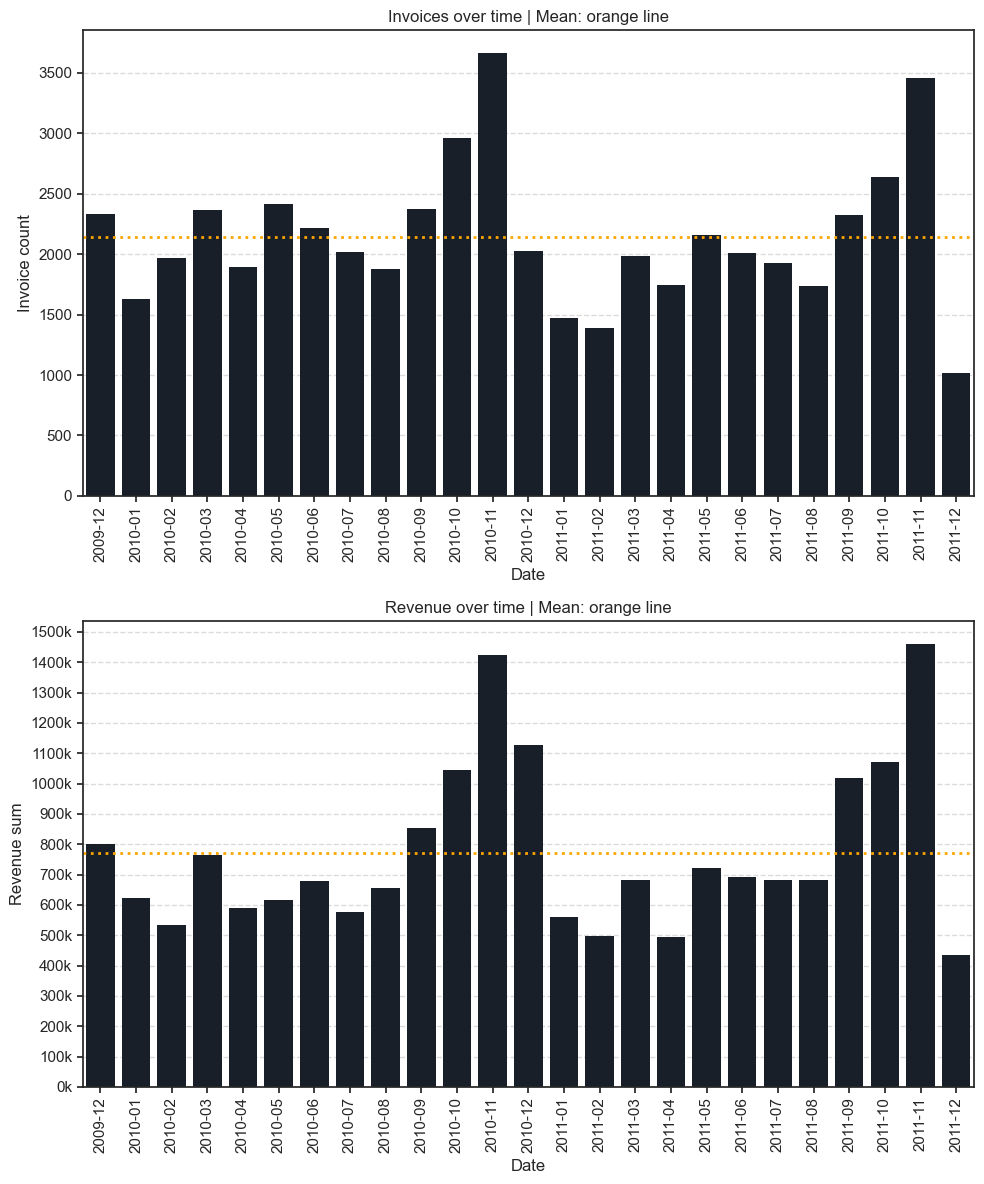

In [19]:
sns.set_theme(
    style="white"
    )
f, (ax1, ax2) = plt.subplots(2,1, figsize=(10, 12))

(
    so.Plot(
        data=time_trend_invoices_count,
        x="InvoiceDate_YYYYMM",
        y="invoice_count"
        )       
    .add(
        so.Bar(
            alpha=1, 
            color="#191f29"
            )
        )
    .scale(
        y=so.Continuous().tick(every=500)
        )   
    .label(
        title="Invoices over time | Mean: orange line",
        x="Date",
        y="Invoice count",
        legend=False
        )
    .on(ax1)
    .plot()
)

(
    so.Plot(
        data=time_trend_revenue_sum,
        x="InvoiceDate_YYYYMM",
        y="revenue_sum"
        )       
    .add(
        so.Bar(
            alpha=1, 
            color="#191f29"
            )
        )
    .scale(
        y=so.Continuous().tick(every=100000)
        )   
    .label(
        title="Revenue over time | Mean: orange line",
        x="Date",
        y="Revenue sum",
        legend=False
        )
    .on(ax2)
    .plot()
)

ax1.axhline(y=(time_trend_invoices_count["invoice_count"].mean() ), linewidth=2, color='orange', ls=':')
ax1.yaxis.set_tick_params(which="both", left=True, length=4, rotation=0)
ax1.yaxis.grid(True, linestyle="--", alpha=0.7)
ax1.xaxis.set_tick_params(which="both", left=True, length=4, rotation=90)
ax1.yaxis.grid(True, linestyle="--", alpha=0.7)
ax1.set_axisbelow(True)

ax2.axhline(y=(time_trend_revenue_sum["revenue_sum"].mean() ), linewidth=2, color='orange', ls=':')
ax2.yaxis.set_tick_params(which="both", left=True, length=4, rotation=0)
ax2.yaxis.grid(True, linestyle="--", alpha=0.7)
ax2.xaxis.set_tick_params(which="both", left=True, length=4, rotation=90)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
ax2.yaxis.grid(True, linestyle="--", alpha=0.7)
ax2.set_axisbelow(True)

plt.tight_layout()
palette = sns.color_palette()
plt.show()

### Answer

In [20]:
display(md(f'''
  The "Invoices over time" and "Revenue over time" charts show the individual months in which the values above the reference level for the entire period presented was exceeded.\n
  Above the average, the period from the September to the December/January stands out clearly, ending abruptly.\n
  This can easily be linked to the Christmas and New Year period, when many retail sectors experience increased traffic.\n
  Less visible, but still present, is the increase in the number of invoices in May, which then steadily declines until September, when the aforementioned holiday season begins.\n
  There are also individual months outside this period, but this is not seasonal in nature.
  '''))


  The "Invoices over time" and "Revenue over time" charts show the individual months in which the values above the reference level for the entire period presented was exceeded.

  Above the average, the period from the September to the December/January stands out clearly, ending abruptly.

  This can easily be linked to the Christmas and New Year period, when many retail sectors experience increased traffic.

  Less visible, but still present, is the increase in the number of invoices in May, which then steadily declines until September, when the aforementioned holiday season begins.

  There are also individual months outside this period, but this is not seasonal in nature.
  

## 4.2. Who are the top 10% of customers in terms of purchase value? What percentage of total sales do they generate?

In [21]:
# sum customer revenue
top_10 = df.groupby("Customer ID").agg(customer_revenue=("Revenue", "sum")).sort_values(by="customer_revenue", ascending=False)
# set 10% revenue limit
mask = top_10["customer_revenue"].quantile(0.9) < top_10["customer_revenue"]
# top 10% customers
top_10 = top_10[mask].reset_index()
# transactions of 10% customers
top_10_customers_transactions = pd.merge(df, top_10["Customer ID"], on="Customer ID", how="inner")

# pct of top 10% customers revenue in all customers revenue
top_10_revenue = top_10["customer_revenue"].sum()
total_revenue = df["Revenue"].sum()
top_10_pct = int(round((top_10_revenue / total_revenue) * 100, 0))

# pct of top 10% customers count in all customers count
top_10_count = top_10["Customer ID"].count()
total_count = df["Customer ID"].drop_duplicates().count()
top_10_count_pct = int(round((top_10_count / total_count) * 100, 0))

In [22]:
top_10_country_count = top_10_customers_transactions[["Customer ID","Country"]].drop_duplicates().value_counts(subset="Country", ascending=False).iloc[0]
top_10_country_count_pct = int(round((top_10_country_count / top_10_count) * 100, 0))
top_10_country = top_10_customers_transactions[["Customer ID","Country"]].drop_duplicates().value_counts(subset="Country", ascending=False).index[0]

top_10_customers_transactions_products = top_10_customers_transactions["Description"].value_counts(ascending=False).reset_index()

### Answer

In [23]:
display(md(f"Top 10% of customers: which is **{top_10_count}** customers, generates **{int(top_10_revenue)}** revenue. Which is **{top_10_pct}%** of total revenue."))

display(md(f"They are mostly from **{top_10_country}**. **{top_10_country_count}** of them are from there. It is **{top_10_country_count_pct}%** of all top 10% customers."))

display(md(f"**{list(top_10_customers_transactions_products["Description"].head(5))}** are their top 5 favourite products. They bought them the most."))

Top 10% of customers: which is **595** customers, generates **10611304** revenue. Which is **55%** of total revenue.

They are mostly from **United Kingdom**. **515** of them are from there. It is **87%** of all top 10% customers.

**['WHITE HANGING HEART T-LIGHT HOLDER', 'REGENCY CAKESTAND 3 TIER', 'JUMBO BAG RED RETROSPOT', 'ASSORTED COLOUR BIRD ORNAMENT', 'LUNCH BAG  BLACK SKULL.']** are their top 5 favourite products. They bought them the most.

## 4.3. Market basket analysis: which products are most often purchased together? (simple approach: transactions with multiple items, check for repetitions)

In [24]:
# transactions with multiple items
transactions_grouped = df
transactions_grouped["item_count"] = df.groupby("Invoice")["Invoice"].transform("count")
transactions_grouped = transactions_grouped[transactions_grouped["item_count"] > 1]

# create pairs of products in invoices group
basket_pairs = []
for invoice, group in transactions_grouped.groupby("Invoice"):
    items = group['Description'].unique()  # unique items in invoice
    pairs = list(combinations(sorted(items), 2))  # all pairs (sorted-> A,B == B,A)
    basket_pairs.extend(pairs)

# top 10 of repeating products
pair_counts = pd.Series(basket_pairs).value_counts().head(10).reset_index()
pair_counts[['product_a', 'product_b']] = pd.DataFrame(pair_counts['index'].tolist(), index=pair_counts.index)
pair_counts = pair_counts[["product_a","product_b","count"]].rename(columns={"count":"times_purchased_together"})

### Answer

In [25]:
display(pair_counts)
display(md(f"Table below shows top 10 products pairs. Products A and B are often purchased together, so they can be promoted as a bundle. Customers who buy A often add B, so it is worth displaying them next to each other."))

,product_a,product_b,times_purchased_together
0,RED HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER,1254
1,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,1124
2,JUMBO BAG RED RETROSPOT,JUMBO STORAGE BAG SUKI,1105
3,STRAWBERRY CERAMIC TRINKET BOX,SWEETHEART CERAMIC TRINKET BOX,1087
4,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,1044
5,JUMBO BAG RED RETROSPOT,JUMBO SHOPPER VINTAGE RED PAISLEY,1011
6,HEART OF WICKER LARGE,HEART OF WICKER SMALL,1007
7,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,975
8,JUMBO BAG RED RETROSPOT,JUMBO BAG STRAWBERRY,936
9,60 TEATIME FAIRY CAKE CASES,PACK OF 60 PINK PAISLEY CAKE CASES,928


Table below shows top 10 products pairs. Products A and B are often purchased together, so they can be promoted as a bundle. Customers who buy A often add B, so it is worth displaying them next to each other.

## 4.4. What is the average order value? How does it change over time? Are there regions/countries with higher AOV?

In [26]:
# revenue sum per invoice
col_dict = {
    "InvoiceDate":"first",
    "InvoiceDate_YYYYMM":"first",
    "Customer ID":"first",
    "Country":"first",
    "Category":"first",
    "Revenue":"sum"
    }

invoice_revenue = df.groupby("Invoice", as_index=False).agg(col_dict)

In [27]:
# average order value
avg_order = round(invoice_revenue["Revenue"].mean(),2)

# average order over time
avg_order_by_month = invoice_revenue.groupby("InvoiceDate_YYYYMM", as_index=False)["Revenue"].mean()

# average order value per Country
avg_order_by_country = invoice_revenue.groupby("Country", as_index=False).agg(AverageRevenue=("Revenue", "mean"), InvoiceCount=("Invoice", "count")).sort_values(by="AverageRevenue", ascending=False)
avg_order_by_country["AverageRevenue"] = round(avg_order_by_country["AverageRevenue"],2)

### Answer

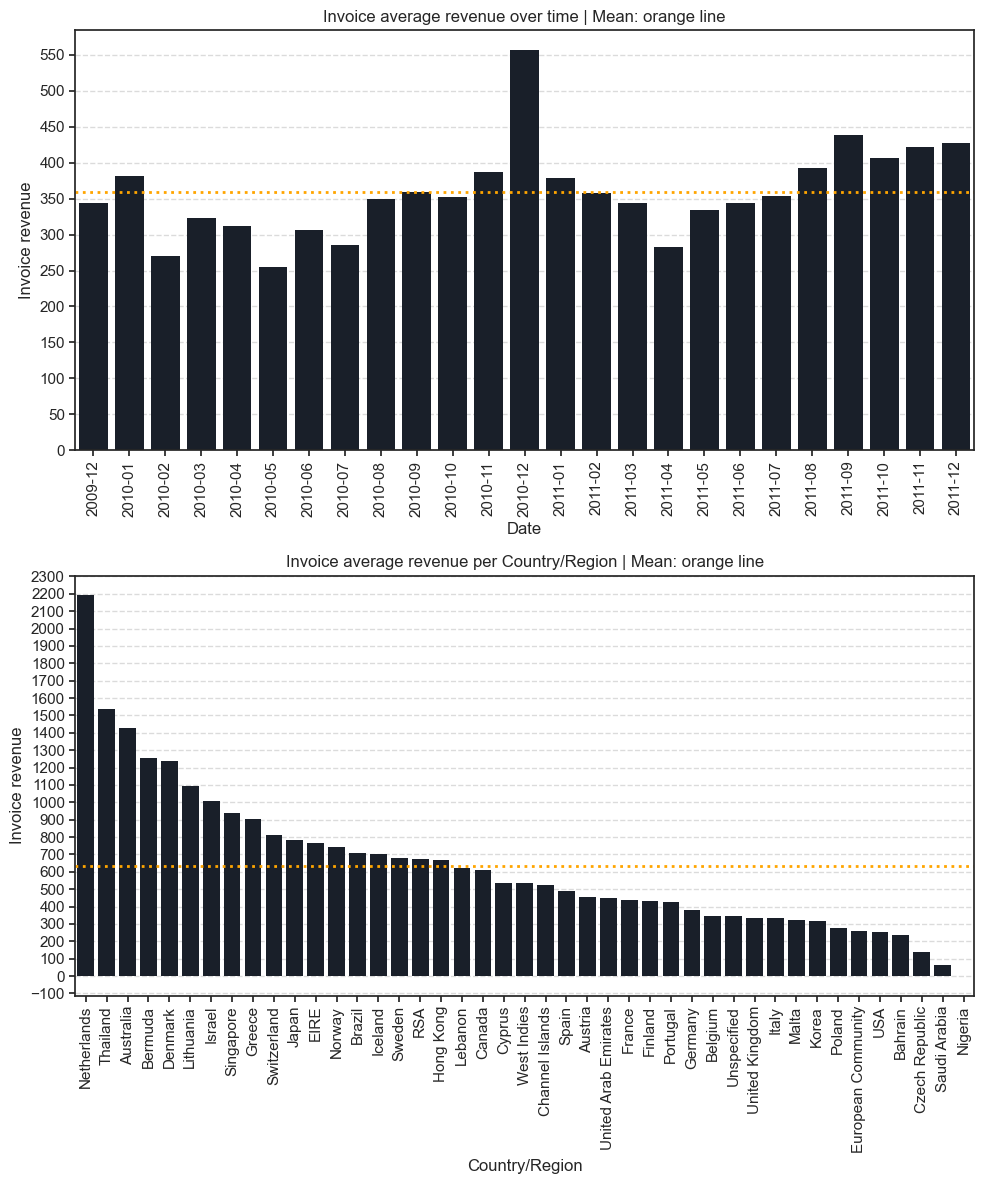

**Top 10 countries per Invoice revenue**

,Country,AverageRevenue,InvoiceCount
26,Netherlands,2194.10,250
37,Thailand,1535.27,2
0,Australia,1428.45,117
4,Bermuda,1253.14,1
10,Denmark,1240.40,53
24,Lithuania,1092.29,6
19,Israel,1009.75,11
33,Singapore,939.87,14
16,Greece,904.55,21
36,Switzerland,810.80,123


In [28]:
sns.set_theme(
    style="white"
    )
f, (ax1, ax2) = plt.subplots(2,1, figsize=(10, 12))

(
    so.Plot(
        data=avg_order_by_month,
        x="InvoiceDate_YYYYMM",
        y="Revenue"
        )       
    .add(
        so.Bar(
            alpha=1, 
            color="#191f29"
            )
        )
    .scale(
        y=so.Continuous().tick(every=50)
        )   
    .label(
        title="Invoice average revenue over time | Mean: orange line",
        x="Date",
        y="Invoice revenue",
        legend=False
        )
    .on(ax1)
    .plot()
)

(
    so.Plot(
        data=avg_order_by_country,
        x="Country",
        y="AverageRevenue"
        )       
    .add(
        so.Bar(
            alpha=1, 
            color="#191f29"
            )
        )
    .scale(
        y=so.Continuous().tick(every=100)
        )   
    .label(
        title="Invoice average revenue per Country/Region | Mean: orange line",
        x="Country/Region",
        y="Invoice revenue",
        legend=False
        )
    .on(ax2)
    .plot()
)

ax1.axhline(y=(avg_order_by_month["Revenue"].mean() ), linewidth=2, color='orange', ls=':')
ax1.yaxis.set_tick_params(which="both", left=True, length=4, rotation=0)
ax1.yaxis.grid(True, linestyle="--", alpha=0.7)
ax1.xaxis.set_tick_params(which="both", left=True, length=4, rotation=90)
ax1.yaxis.grid(True, linestyle="--", alpha=0.7)
ax1.set_axisbelow(True)

ax2.axhline(y=(avg_order_by_country["AverageRevenue"].mean() ), linewidth=2, color='orange', ls=':')
ax2.yaxis.set_tick_params(which="both", left=True, length=4, rotation=0)
ax2.yaxis.grid(True, linestyle="--", alpha=0.7)
ax2.xaxis.set_tick_params(which="both", left=True, length=4, rotation=90)
ax2.yaxis.grid(True, linestyle="--", alpha=0.7)
ax2.set_axisbelow(True)

plt.tight_layout()
palette = sns.color_palette()
plt.show()

display(md("**Top 10 countries per Invoice revenue**"))
display(avg_order_by_country.head(10))

In [29]:
display(md(f'''
  The "Invoice revenue over time" show the individual months in which the revenue above the reference level for the entire period presented was exceeded.\n
  Above the average, the period from the September to the December/January stands out clearly, ending abruptly.\n
  This can easily be linked to the Christmas and New Year period, when many retail sectors experience increased traffic.\n
  Like in general point of view - the increased number of invoices in May does not effect in Revenue per invoice. As it was seen: the number of invoices did not generate higher revenue, so it effects on low average revenue per invoice.
  '''))

display(md(f'''
  There are several countries with average invoice revenue higher than average. The attached table shows the top 10 countries.\n
  The highest invoice revenue is generated by **{avg_order_by_country.head(10).iloc[0,0]}** with a number of invoices amounting to **{avg_order_by_country.head(10).iloc[0,2]}**.
  '''))



  The "Invoice revenue over time" show the individual months in which the revenue above the reference level for the entire period presented was exceeded.

  Above the average, the period from the September to the December/January stands out clearly, ending abruptly.

  This can easily be linked to the Christmas and New Year period, when many retail sectors experience increased traffic.

  Like in general point of view - the increased number of invoices in May does not effect in Revenue per invoice. As it was seen: the number of invoices did not generate higher revenue, so it effects on low average revenue per invoice.
  


  There are several countries with average invoice revenue higher than average. The attached table shows the top 10 countries.

  The highest invoice revenue is generated by **Netherlands** with a number of invoices amounting to **250**.
  

## 4.5. Customer retention: how many customers return after their first purchase? What is the difference between “one-time” and “returning” customers in terms of value?

In [30]:
# remove unkown customers
retention = df[df["Customer ID"].notna()]

# revenue sum per invoice
col_dict = {
    "InvoiceDate":"first",
    "InvoiceDate_YYYYMM":"first",
    "Customer ID":"first",
    "Country":"first",
    "Category":"first",
    "Revenue":"sum"
    }

retention = retention.groupby("Invoice", as_index=False).agg(col_dict).sort_values(by=["Customer ID", "InvoiceDate"], ascending=True)

# invoices per customer
order_count = retention["Customer ID"].value_counts().reset_index()

# customer types
all_customers = order_count["Customer ID"].count()
one_time_customers = order_count[order_count["count"] == 1]["Customer ID"].count()
one_time_ratio = round((one_time_customers / all_customers) * 100,1)
returning_customers = order_count[order_count["count"] > 1]["Customer ID"].count()
returning_ratio = round((returning_customers / all_customers) * 100,1)

# one-time and returning average revenue
one_time_customers_list = order_count.copy()
one_time_customers_list = one_time_customers_list[one_time_customers_list["count"] == 1]
one_time_customers_list["CustomerType"] = "one-time"
returning_customers_list = order_count.copy()
returning_customers_list = returning_customers_list[returning_customers_list["count"] > 1]
returning_customers_list["CustomerType"] = "returning"

customers_type = pd.concat((one_time_customers_list,returning_customers_list))
customers_type_revenue = pd.merge(retention, customers_type[["Customer ID", "CustomerType"]], on="Customer ID")
customers_type_revenue = customers_type_revenue.groupby("CustomerType", as_index=False)["Revenue"].mean().round(2)

In [32]:
# Cohorts
cohorts = retention.copy()
cohorts["FirstOrder"] = cohorts.groupby("Customer ID")["InvoiceDate"].transform("min")
cohorts["CohortMonth"] = cohorts["FirstOrder"].dt.to_period("M")
cohorts["MonthDiff"] = (cohorts["InvoiceDate"].dt.year - cohorts["FirstOrder"].dt.year) * 12 + (cohorts["InvoiceDate"].dt.month - cohorts["FirstOrder"].dt.month)

cohorts = cohorts[["InvoiceDate", "FirstOrder", "MonthDiff", "CohortMonth", "Customer ID", "Invoice"]]
cohorts = cohorts.groupby(["MonthDiff", "CohortMonth"], as_index=False)["Customer ID"].nunique().sort_values(by="MonthDiff", ascending=True)
cohorts_pivot = cohorts.pivot(index="CohortMonth", columns="MonthDiff", values="Customer ID")
first_month_size = cohorts_pivot.iloc[:, 0]

# % retention
retention_matrix = cohorts_pivot.divide(first_month_size, axis=0)
retention_matrix = retention_matrix * 100

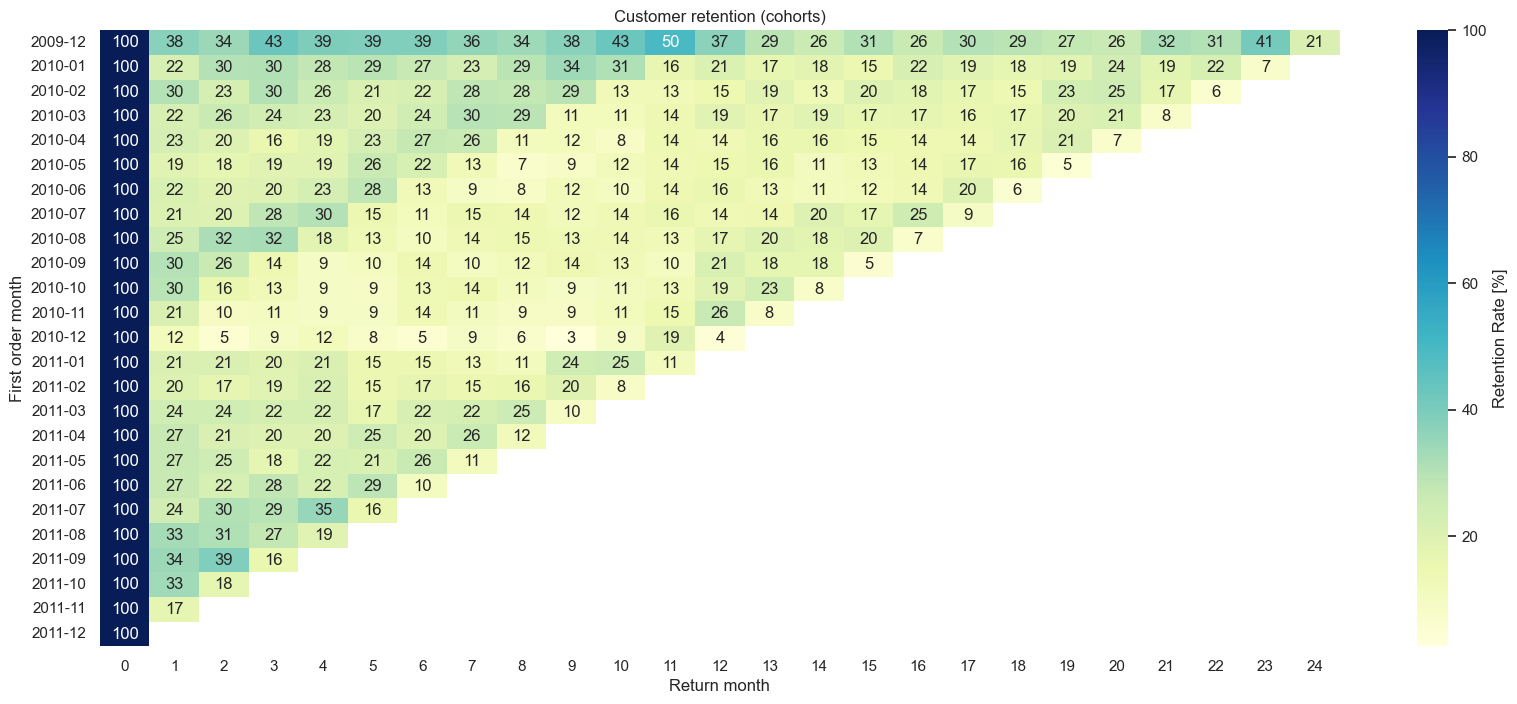

In [33]:
plt.figure(figsize=(20, 8))
ax = sns.heatmap(retention_matrix, 
            annot=True,
            fmt=".0f",
            cmap='YlGnBu',
            cbar_kws={'label': 'Retention Rate [%]'})
ax.set(xlabel="Return month", ylabel="First order month")
plt.title('Customer retention (cohorts)')
plt.show()

### Answer

In [34]:
display(md(f"Of all **{all_customers}** known customers (excluding unknown ‘Customer ID’), **{one_time_customers}** made one-time purchases, which accounts for **{one_time_ratio}%**."))
display(md(f"**{returning_customers}** made subsequent purchases, which represents **{returning_ratio}%**. It can be said that customer retention is high."))
display(md(f"One-time customers place orders worth an average of **{customers_type_revenue.loc[customers_type_revenue["CustomerType"] == "one-time", "Revenue"].item()}**"))                                                                             
display(md(f"Returning customers place orders worth an average of **{customers_type_revenue.loc[customers_type_revenue["CustomerType"] == "returning", "Revenue"].item()}**")) 
display(md(f"The heatmap from the cohort analysis shows a certain pattern, indicating that customers return during the Christmas season. The date of the first order and the month of the next order most often fall within the Christmas season."))

Of all **5942** known customers (excluding unknown ‘Customer ID’), **1461** made one-time purchases, which accounts for **24.6%**.

**4481** made subsequent purchases, which represents **75.4%**. It can be said that customer retention is high.

One-time customers place orders worth an average of **269.44**

Returning customers place orders worth an average of **374.4**

The heatmap from the cohort analysis shows a certain pattern, indicating that customers return during the Christmas season. The date of the first order and the month of the next order most often fall within the Christmas season.

# Summary

In [35]:
display(md(f"An analysis of the Online Retail dataset showed that as many as **22.77%** of transactions lack a customer ID, which is a significant area for improvement in data collection quality. The key conclusion is the enormous concentration of revenue: just **10%** of customers (mainly from the UK) generate as much as **55%** of total sales. Seasonality is clearly evident, with a sharp increase in activity between September and January, which directly correlates with the holiday season. Despite an increase in the number of invoices in May, this does not translate into higher average revenue, suggesting periodic promotions of lower-margin products. The retention rate is high **(75.4%)**, and returning customers generate nearly **40%** higher average order value than one-time customers. Identified anomalies in prices and quantities (including negative values) are not errors, but reflect real business processes such as returns, fees, and write-offs. The use of detected correlations in shopping carts represents ready-made potential for sales optimization through cross-selling."))

An analysis of the Online Retail dataset showed that as many as **22.77%** of transactions lack a customer ID, which is a significant area for improvement in data collection quality. The key conclusion is the enormous concentration of revenue: just **10%** of customers (mainly from the UK) generate as much as **55%** of total sales. Seasonality is clearly evident, with a sharp increase in activity between September and January, which directly correlates with the holiday season. Despite an increase in the number of invoices in May, this does not translate into higher average revenue, suggesting periodic promotions of lower-margin products. The retention rate is high **(75.4%)**, and returning customers generate nearly **40%** higher average order value than one-time customers. Identified anomalies in prices and quantities (including negative values) are not errors, but reflect real business processes such as returns, fees, and write-offs. The use of detected correlations in shopping carts represents ready-made potential for sales optimization through cross-selling.